# GCAP3226 Week 3 — Demo
## MSW case: stacked bar → simple / multiple regression → before–after support

**Not graded.** Follow the instructor; run cells top to bottom in **your fork / Codespace**.

**Dataset:** `week3.csv` (same folder as this notebook; prepared from the full survey file).  

### Aims for this demo
1. Read association first as **row % + stacked bar**.
2. **Scenario 1 — simple linear regression** (one X).
3. **Scenario 2 — multiple linear regression** (two Xs).
4. **Scenario 3 — multiple linear regression** with recycling effort + demographics (more X).
5. **Scenario 4 — compare** `support_info` and `support_after_info`.
6. Keep the hard rule: **association ≠ causation**; **non-probability** sample (n = 97).

Survey wording is on the PPT — this notebook uses **column names**.

### Using the sample AI prompts in code cells
Each code cell starts with a plain-language **Input → Process → Output** prompt. That prompt is enough to generate the working code shown underneath — when you state the requirement clearly in natural language and keep the task at a sensible scope (not too complicated), GenAI can usually produce correct code.

You do **not** need to audit every line of code. Instead, **critically review the output** (tables, charts, coefficients): does it match the question, the variables, and this sample? If something looks doubtful, ask GenAI to **explain the steps it took** and to **re-generate** the result — then check the new output again.


## 0. Decision rule

**Regression analysis helps when** your goal is to describe how a response **Y** is associated with a small set of exploratory variables **X** in many observed cases (and/or to predict **Y**).

**Hard rule:** a coefficient describes a pattern **in this sample**, not proof that X *causes* Y for Hong Kong as a whole.


## 1. Variables in `week3.csv`

| Role | Column | Meaning | Scale / coding |
|------|--------|---------|----------------|
| **Y (response)** | `support_info` | Initial support for MSW charging | 1–5 |
| *(Scenario 4)* | `support_after_info` | Support after landfill + Korea information | 1–5 |
| **X1 (exploratory)** | `government_consideration` | Government considered diverse opinions? | 1–5 |
| **X2 (exploratory)** | `fairness` | Polluter-pays charging is fair? | 1–5 |
| Behaviour | `recycling_effort` | Time / effort to recycle | 1–4 |
| Demographic | `age_group` | Age-band **midpoint** (years) | e.g. 18–24 → 21; 65+ → 70 |
| Demographic | `monthly_income` | Household income-band **midpoint** (HK$) | e.g. Below15k → 7500; Above70k → 85000 |
| Demographic | `education` | Highest education (ordered) | 1 Primary… → 4 Master+ |

Demographics were recoded from one-hot survey columns (see `prepare_week3_csv.py` if you need the recipe).


## 2. Imports and load

Raise your hand only if import or file load fails.


In [1]:
# --- Sample AI prompt (Input → Process → Output) ---
# Input: I am starting a Python notebook for a survey analysis demo.
# Process: Write Python code to import packages for tables, charts, and linear regression.
#   Set up a simple way to fit a regression and print each coefficient clearly.
#   Keep code short with brief comments.
#   Add comments to key Python code.
# Output: Imports ready to run, helper(s) defined, and a short "Imports OK" message.
# --- End prompt ---

# Load libraries: tables (pandas), numbers (numpy), charts (matplotlib), OLS (statsmodels)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

def fit_ols(y, X):
    """Fit OLS with an intercept term; return the fitted model."""
    # add_constant inserts the intercept column; .fit() estimates the coefficients
    return sm.OLS(y, sm.add_constant(X)).fit()


def print_ols(model, title):
    """Print each coefficient, R-squared, and n for this sample."""
    print(title)
    # Intercept = predicted Y when all X = 0 (often not substantively meaningful here)
    print(f"  Intercept (β0): {float(model.params['const']):.3f}")
    for name in model.params.index:
        if name == "const":
            continue
        # Slope: average change in Y linked to a 1-unit higher X (holding other X fixed in MLR)
        print(f"  β {name}: {float(model.params[name]):.3f}")
    print(f"  R-squared: {model.rsquared:.3f}  (n={int(model.nobs)})")
    print("  Association in this sample only — not causation; non-probability sample.")


print("Imports OK")


Imports OK


In [2]:
# --- Sample AI prompt (Input → Process → Output) ---
# Input: A file named week3.csv in the same folder as this notebook.
# Process: Write Python code to load it into a dataframe. 
#   Add comments to key Python code.
# Output: Print the resolved file path, the shape (rows × columns), and show the first few rows.
# --- End prompt ---

# Load week3.csv from THIS repo folder (Codespace / fork)
from pathlib import Path

DATA_FILE = "week3.csv"

def load_week3_data():
    # Try the notebook folder, then the current working directory
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            print("Using data file:", p.resolve())
            return pd.read_csv(p)  # read CSV into a dataframe
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Open this notebook from your Week 3 fork / Codespace."
    )

df = load_week3_data()
print("shape:", df.shape)  # (rows, columns) = respondents × variables
df.head()  # first few rows — quick visual check


Using data file: /workspaces/GCAP3226_week3/week3.csv
shape: (97, 12)


,ID,support_info,support_after_info,government_consideration,fairness,policy_helpfulness,waste_severity,recycling_effort,age_group,monthly_income,education,education_label
0,1,1,1,1,1,1,3,1,29.5,22500.5,4,Master or above
1,2,5,5,5,5,4,2,2,39.5,7500.0,4,Master or above
2,3,3,5,4,5,2,3,1,29.5,22500.5,4,Master or above
3,4,1,2,1,2,2,3,2,29.5,60000.5,4,Master or above
4,5,1,3,3,4,1,3,2,49.5,22500.5,2,Secondary


In [3]:
# --- Sample AI prompt (Input → Process → Output) ---
# Input: Survey dataframe already loaded.
# Process: Write Python code to summarise all columns
#   Add comments to key Python code.
# Output: A rounded summary table for these columns, plus a missing-value count for each.
# --- End prompt ---

# Columns we will use in the demo (Y, perceptions, behaviour, demographics)
cols = [
    "support_info",
    "support_after_info",
    "government_consideration",
    "fairness",
    "recycling_effort",
    "age_group",
    "monthly_income",
    "education",
]
# describe() = mean, sd, min/max, etc.; round for readability
print(df[cols].describe().round(2))
print("\nMissing values:")
print(df[cols].isna().sum())  # how many blanks in each column


       support_info  support_after_info  government_consideration  fairness  \
count         97.00                97.0                     97.00     97.00   
mean           2.84                 3.1                      2.51      2.95   
std            1.27                 1.1                      1.08      1.16   
min            1.00                 1.0                      1.00      1.00   
25%            2.00                 2.0                      2.00      2.00   
50%            3.00                 3.0                      3.00      3.00   
75%            4.00                 4.0                      3.00      4.00   
max            5.00                 5.0                      5.00      5.00   

       recycling_effort  age_group  monthly_income  education  
count             97.00      97.00           97.00      97.00  
mean               2.22      37.32        47990.06       3.45  
std                0.71      12.02        23956.36       0.72  
min                1.00      21.

## 3. Warm-up — row % and stacked bar (perception × support)

**Hypothesis:** Among respondents in this sample, as **perceived government consideration** increases, the share at **higher support** levels may also be higher.

We start with counts → **row percentages** → **stacked bar** (two Likert items).  
Watch small groups (especially X = 5).


In [4]:
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe with the analysis columns; drop rows with missing values for those columns.
# Process: Write Python code to cross-tabulate government_consideration (rows) by support_info (columns).
#   Also compute row percentages and group sizes. Scale monthly_income to units of 10,000
#   so it is more comparable with other variables.
#   Add comments to key Python code.
# Output: Printed counts table, row-percentage table, and n in each government_consideration group.
# --- End prompt ---

# Keep only rows with complete data on the analysis columns
work = df[cols].dropna().copy()
# Rescale income to HK$10,000 units so later regression slopes are easier to read
work["monthly_income_10k"] = work["monthly_income"] / 10_000

# Counts: how many people in each (government_consideration, support_info) cell
counts = pd.crosstab(work["government_consideration"], work["support_info"])
# Row %: within each government_consideration level, the mix of support answers
row_pct = pd.crosstab(
    work["government_consideration"],
    work["support_info"],
    normalize="index",  # each row sums to 1
) * 100

print("Counts:")
print(counts)
print("\nRow percentages (% within each government_consideration group):")
print(row_pct.round(1))
print("\nRow n:")
print(counts.sum(axis=1))  # sample size in each government_consideration group


Counts:
support_info               1   2   3   4  5
government_consideration                   
1                         16   6   0   0  0
2                          3  10   6   3  2
3                          1   3  14  12  3
4                          0   0   3  11  2
5                          0   0   0   1  1

Row percentages (% within each government_consideration group):
support_info                 1     2     3     4     5
government_consideration                              
1                         72.7  27.3   0.0   0.0   0.0
2                         12.5  41.7  25.0  12.5   8.3
3                          3.0   9.1  42.4  36.4   9.1
4                          0.0   0.0  18.8  68.8  12.5
5                          0.0   0.0   0.0  50.0  50.0

Row n:
government_consideration
1    22
2    24
3    33
4    16
5     2
dtype: int64


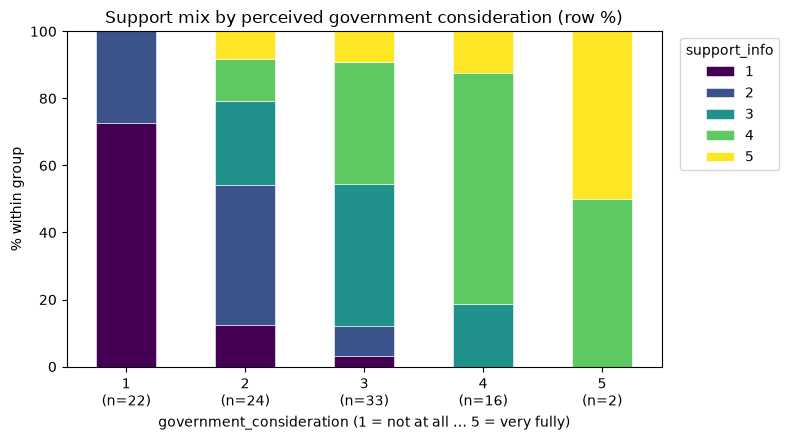

In [5]:
# --- Sample AI prompt (Input → Process → Output) ---
# Input: the loaded dataframe column government_consideration and support_info
# Process: Write Python code to draw a stacked bar chart of the support mix within each
#   government_consideration group.
#   Add comments to key Python code.
# Output: A stacked bar chart with a clear title and a legend.
# --- End prompt ---

# Stacked bar of row % — each bar is one government_consideration group
row_n = counts.sum(axis=1)  # n per group (for x-axis labels)
ax = row_pct.plot(
    kind="bar",
    stacked=True,  # segments = support_info levels
    figsize=(8, 4.5),
    colormap="viridis",
    edgecolor="white",
    linewidth=0.4,
)
ax.set_xlabel("government_consideration (1 = not at all … 5 = very fully)")
ax.set_ylabel("% within group")
ax.set_title("Support mix by perceived government consideration (row %)")
ax.legend(title="support_info", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 100)
# Label each bar with the group level and its n
ax.set_xticklabels([f"{int(level)}\n(n={int(row_n.loc[level])})" for level in row_pct.index])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Scenario 1 — Simple linear regression

`support_info ≈ β₀ + β₁ × government_consideration`

- **β₁:** expected change in Y for a one-unit increase in X1 (**this sample**).  
- **R²:** share of variance in Y accounted for by this line (higher ≠ causal).

Likert scores are treated as numbers — a compact summary, not the gold standard for two categories.


In [3]:
# --- Sample AI prompt (Input → Process → Output) ---
# Input: work dataframe; response = support_info; exploratory variable = government_consideration.
# Process: Write Python code to run a simple linear regression for this sample.
#   Add comments to key Python code.
# Output: Printed coefficients, R-squared, and n.
# --- End prompt ---

# Scenario 1: simple linear regression — one Y, one X
y = work["support_info"]  # response
X1 = work[["government_consideration"]]  # exploratory variable (needs dataframe shape)

slr = fit_ols(y, X1)  # estimate intercept + slope
print_ols(slr, "Scenario 1: support_info ~ government_consideration")


NameError: name 'work' is not defined

### Interpretation

*In this sample, a one-point higher score on government consideration is associated with about **0.87** points higher initial support (1–5 scale), on average.*

This **does not** imply that improving consideration **will cause** support to rise across Hong Kong.


## Scenario 2 — Multiple linear regression (two perception variables)

`support_info ≈ β₀ + β₁ × government_consideration + β₂ × fairness`

Each coefficient is estimated **holding the other variable constant** — a first step toward separating overlapping influences.


In [4]:
# --- Sample AI prompt (Input → Process → Output) ---
# Input: Same response support_info; exploratory variables = government_consideration and fairness.
# Process: Write Python code to run a regression with two exploratory variables. Compare the
#   government_consideration coefficient with the one-variable model.
#   Add comments to key Python code.
# Output: Printed coefficients and a short comparison of the government_consideration coefficient.
# --- End prompt ---

# Scenario 2: multiple linear regression — same Y, two X's
X2 = work[["government_consideration", "fairness"]]

mlr2 = fit_ols(y, X2)  # slopes are "holding the other X fixed"
print_ols(mlr2, "Scenario 2: support_info ~ government_consideration + fairness")
print()
# Compare the government_consideration slope before vs after adding fairness
b1 = float(slr.params["government_consideration"])
b2 = float(mlr2.params["government_consideration"])
print(f"Compare β for government_consideration: simple linear regression {b1:.3f} → multiple linear regression {b2:.3f}")
print("Did that coefficient get smaller once fairness is included?")


NameError: name 'work' is not defined

## Scenario 3 — Multiple linear regression (+ behaviour & demographics)

Add recycling effort plus age, education, and household income:

`support_info ≈ β₀ + β₁×government_consideration + β₂×fairness
              + β₃×recycling_effort
              + β₄×age_group + β₅×education + β₆×monthly_income_10k`

**Note on income:** we use `monthly_income_10k` (= HK$ / 10,000) so a coefficient means “associated change in support per **HK$10,000** of midpoint income,” which is easier to say aloud than per single dollar.

**Still:** association in this sample only; behaviour and demographics may also be correlated with perceptions. We focus on **coefficient direction and size**.


In [ ]:
# --- Sample AI prompt (Input → Process → Output) ---
# Input: The survey dataframe already loaded.
# Process: Write Python code to run a regression for initial support using consideration, fairness,
#   recycling effort, age, education, and income (income in units of 10,000).
#   Add comments to key Python code.
# Output: Coefficients, R-squared, and n for this model.
# --- End prompt ---

# Scenario 3: add recycling effort + demographics to the perception model
need = [
    "support_info",
    "support_after_info",  # kept for Scenario 4
    "government_consideration",
    "fairness",
    "recycling_effort",
    "age_group",
    "education",
    "monthly_income",
]
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(
        f"Missing {missing} in week3.csv — re-run prepare_week3_csv.py, then re-load the CSV."
    )

# Rebuild work with complete cases on this wider variable list
work = df[need].dropna().copy()
work["monthly_income_10k"] = work["monthly_income"] / 10_000  # income in HK$10k units
y = work["support_info"]

X3 = work[
    [
        "government_consideration",
        "fairness",
        "recycling_effort",
        "age_group",
        "education",
        "monthly_income_10k",
    ]
]

mlr3 = fit_ols(y, X3)
print_ols(mlr3, "Scenario 3: support_info ~ perceptions + recycling_effort + demographics")


### Brief interpretation (Scenario 3)

In this sample, **government consideration** and **fairness** still show **clear positive** associations with initial support after we also include recycling effort and demographics. The β for consideration is **smaller** than in the simple regression (and a bit smaller than in the model with two exploratory variables) because part of the raw association is **shared with** fairness (and, to a lesser extent, other covariates). Read the Scenario 3 coefficient as: *among respondents who look similar on the other variables in the model, higher consideration is still linked with higher support* — **association, not proof that changing consideration would raise citywide support**.

**Recycling effort, age, education, and income** have **coefficients near zero** here relative to the perception terms. With n = 97 and coarse survey measures, treat those small coefficients cautiously — do **not** over-read their signs, and do **not** claim those factors never matter in Hong Kong.


## Scenario 4 — `support_info` vs `support_after_info`

Respondents answered support **before** and **after** reading brief information (landfill pressure + Korea recycling — wording on the PPT).

Because the **same people** answer twice, we look at **paired changes** for **all** respondents (n = 97):
1. Means before vs after, and how many people increased / decreased / stayed the same.  
2. A **bar chart of change counts** (each possible change value is a category; every person appears once).

**Question for class:** Did support tend to rise, fall, or stay similar **in this sample** after the information?

Still refuse: “an information campaign will raise support across Hong Kong.”


In [2]:
# --- Sample AI prompt (Input → Process → Output) ---
# Input: work with support_info (before) and support_after_info (after) for all respondents.
# Process: Write Python code to compute each person's change (after − before). Summarise means and
#   how many people increased, decreased, or stayed the same. Make a before×after crosstab.
#   No hypothesis test.
#   Add comments to key Python code.
# Output: Printed means, mean change, change counts, and the crosstab.
# --- End prompt ---

# Scenario 4: describe before → after support for every respondent (no hypothesis test)
before = work["support_info"]
after = work["support_after_info"]
delta = after - before  # person-level change (positive = increased support)

print("Mean support_info (before):", round(before.mean(), 3))
print("Mean support_after_info (after):", round(after.mean(), 3))
print("Mean change (after − before):", round(delta.mean(), 3))
print()
print("Change counts (all n =", len(delta), "):")
print(f"  Increased: {(delta > 0).sum()}")
print(f"  Decreased: {(delta < 0).sum()}")
print(f"  Unchanged: {(delta == 0).sum()}")
print()
print("Crosstab (rows = before, columns = after):")
print(pd.crosstab(before, after))  # joint distribution of before × after scores


NameError: name 'work' is not defined

In [1]:
# --- Sample AI prompt (Input → Process → Output) ---
# Input: before scores, after scores, and each person's change for all respondents.
# Process: Write Python code for two charts: one mean support before vs after; the other a bar chart
#   of counts of each discrete change value.
#   Add comments to key Python code.
# Output: A two-panel figure with titles, axis labels, n shown, and mean change noted on the right.
# --- End prompt ---

# Two panels: (left) mean before vs after; (right) how many people had each change value
# Change scores are discrete (−3, −2, …), so use a bar chart — not a histogram.

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# Left — compare average support before vs after (same people)
axes[0].bar(
    ["Before\n(support_info)", "After\n(support_after_info)"],
    [before.mean(), after.mean()],
    color=["C0", "C1"],
    edgecolor="white",
)
axes[0].set_ylim(1, 5)
axes[0].set_ylabel("Mean score (1–5)")
axes[0].set_title(f"Mean support (n = {len(before)})")

# Right — count of respondents at each discrete change value
change_counts = delta.value_counts().sort_index()
axes[1].bar(
    change_counts.index.astype(str),
    change_counts.values,
    color="C2",
    edgecolor="white",
)
axes[1].set_xlabel("Change = support_after_info − support_info")
axes[1].set_ylabel("Number of respondents")
axes[1].set_title(f"Bar chart of change counts (all n = {len(delta)})")
# Annotate mean change on the plot
axes[1].text(
    0.98,
    0.95,
    f"mean change = {delta.mean():.3f}",
    transform=axes[1].transAxes,
    ha="right",
    va="top",
)

plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

### Brief interpretation (Scenario 4)

In **this sample**, mean support rises from about **2.84 → 3.10** (mean change ≈ **+0.27**). The bar chart uses **every respondent once**: many people do not move (bar at 0); more people increase than decrease.

Describe what you see in the sample — do **not** turn this into a claim that the information **caused** a Hong Kong–wide shift (non-probability sample; short prompt; before–after inside one survey only).


## Bridge to the graded exercise (`W3_msw_inclass.ipynb`)

| Task | What you do |
|------|-------------|
| **1** | Your own **row-% stacked bar** (group ≠ `government_consideration`) + trend in your words |
| **2** | multiple linear regression on `support_info` with gov + fairness + **`policy_helpfulness`** + **`waste_severity`** + short interpretation |
| **3** | **Write your own** IPO prompt → simple linear regression: `support_info` vs `fairness` |
| **Submit** | Commit & push → Moodle **GitHub URL** |

Reuse the demo’s **Input → Process → Output** prompts (**Write Python code** in Process). Keep **association** language and this sample’s limits.
